In [ ]:

!pip install -q timm==0.9.16 gdown scikit-learn
!git clone -q --depth 1 https://github.com/SiyuanYan1/PanDerm /content/PanDerm 2>/dev/null || true

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.8 MB/s eta 0:00:00


In [ ]:

ZIP_PATH   = "/content/MILK10k_Split (2).zip"
EPOCHS     = 80
BATCH_SIZE = 6
ACCUM_STEPS= 2
BASE_LR    = 5e-4
LAYER_DECAY= 0.65
DROP_PATH  = 0.2
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 1
LABEL_SMOOTHING = 0.1
USE_GRAD_CKPT = False
GRADCAM_EVERY = 1
SEED = 42

PANDERM_GDRIVE_ID = "1SwEzaOlFV_gBKf2UzeowMC8z9UH7AQbE"
CKPT_PATH = "/content/panderm_ll_data6_checkpoint-499.pth"

In [ ]:
# EXTRACT ZIP + LOAD METADATA AND GROUND TRUTH

import os
import zipfile
import pandas as pd

ZIP_PATH = "/content/MILK10k_Split (2).zip"
EXTRACT_DIR = "/content/data"

print("Extracting dataset...")
print("=" * 60)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extraction completed.")
print()

BASE_DIR = "/content/data/MILK10k_Split"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print("Train folder:", TRAIN_DIR)
print("Val folder  :", VAL_DIR)
print("Test folder :", TEST_DIR)

TRAIN_METADATA = os.path.join(TRAIN_DIR, "Metadata.csv")
TRAIN_GT       = os.path.join(TRAIN_DIR, "GroundTruth.csv")

VAL_METADATA = os.path.join(VAL_DIR, "Metadata.csv")
VAL_GT       = os.path.join(VAL_DIR, "GroundTruth.csv")

TEST_METADATA = os.path.join(TEST_DIR, "Metadata.csv")
TEST_GT       = os.path.join(TEST_DIR, "GroundTruth.csv")

print("\nChecking CSV files...")
print("=" * 60)

csv_paths = [
    TRAIN_METADATA,
    TRAIN_GT,
    VAL_METADATA,
    VAL_GT,
    TEST_METADATA,
    TEST_GT
]

for path in csv_paths:
    print(
        "FOUND   :" if os.path.exists(path) else "MISSING :",
        path
    )

train_meta = pd.read_csv(TRAIN_METADATA)
train_gt   = pd.read_csv(TRAIN_GT)

val_meta = pd.read_csv(VAL_METADATA)
val_gt   = pd.read_csv(VAL_GT)

test_meta = pd.read_csv(TEST_METADATA)
test_gt   = pd.read_csv(TEST_GT)

print("\nTRAIN METADATA COLUMNS")
print(train_meta.columns.tolist())

print("\nTRAIN GROUND TRUTH COLUMNS")
print(train_gt.columns.tolist())

CLASS_NAMES = [
    "melanoma",
    "nevus",
    "bcc",
    "scc",
    "keratoses"
]

cls2idx = {
    "melanoma": 0,
    "nevus": 1,
    "bcc": 2,
    "scc": 3,
    "keratoses": 4
}

NUM_CLASSES = len(CLASS_NAMES)

def get_class_from_gt(row):

    if row["MEL"] == 1:
        return "melanoma"

    if row["NV"] == 1:
        return "nevus"

    if row["BCC"] == 1:
        return "bcc"

    if row["SCCKA"] == 1:
        return "scc"

    if row["BKL"] == 1 or row["AKIEC"] == 1:
        return "keratoses"

    return None

def create_samples(split_dir, metadata_df, gt_df):

    gt_mapping = {}

    for _, row in gt_df.iterrows():

        lesion_id = row["lesion_id"]

        class_name = get_class_from_gt(row)

        if class_name is not None:
            gt_mapping[str(lesion_id)] = class_name

    samples = []

    image_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    )

    image_files = []

    for root, dirs, files in os.walk(split_dir):

        for file in files:

            if file.lower().endswith(image_extensions):

                image_files.append(
                    os.path.join(root, file)
                )

    print("\nImages found in:", split_dir)
    print("Total images:", len(image_files))

    isic_to_lesion = {}

    for _, row in metadata_df.iterrows():

        isic_id = str(row["isic_id"])
        lesion_id = str(row["lesion_id"])

        isic_to_lesion[isic_id] = lesion_id

    for image_path in image_files:

        filename = os.path.basename(image_path)

        isic_id = os.path.splitext(filename)[0]

        lesion_id = isic_to_lesion.get(isic_id)

        if lesion_id is None:
            continue

        class_name = gt_mapping.get(lesion_id)

        if class_name is None:
            continue

        label = cls2idx[class_name]

        samples.append(
            (image_path, label)
        )

    return samples

print("\nCreating TRAIN samples...")
train_samples = create_samples(
    TRAIN_DIR,
    train_meta,
    train_gt
)

print("\nCreating VALIDATION samples...")
val_samples = create_samples(
    VAL_DIR,
    val_meta,
    val_gt
)

print("\nCreating TEST samples...")
test_samples = create_samples(
    TEST_DIR,
    test_meta,
    test_gt
)

print("\n" + "=" * 60)
print("FINAL DATASET COUNTS")
print("=" * 60)

print("Train samples      :", len(train_samples))
print("Validation samples :", len(val_samples))
print("Test samples       :", len(test_samples))
print("Total samples      :",
      len(train_samples) +
      len(val_samples) +
      len(test_samples))

print("\nClasses:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

from collections import Counter

print("\nTRAIN CLASS DISTRIBUTION")
print("=" * 60)

train_counts = Counter(
    label for _, label in train_samples
)

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:12s}:",
        train_counts.get(idx, 0)
    )

print("\nVALIDATION CLASS DISTRIBUTION")
print("=" * 60)

val_counts = Counter(
    label for _, label in val_samples
)

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:12s}:",
        val_counts.get(idx, 0)
    )

print("\nTEST CLASS DISTRIBUTION")
print("=" * 60)

test_counts = Counter(
    label for _, label in test_samples
)

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{name:12s}:",
        test_counts.get(idx, 0)
    )

print("\nCell 3 completed successfully.")

Extracting dataset...
Extraction completed.

Train folder: /content/data/MILK10k_Split/train
Val folder  : /content/data/MILK10k_Split/val
Test folder : /content/data/MILK10k_Split/test

Checking CSV files...
FOUND   : /content/data/MILK10k_Split/train/Metadata.csv
FOUND   : /content/data/MILK10k_Split/train/GroundTruth.csv
FOUND   : /content/data/MILK10k_Split/val/Metadata.csv
FOUND   : /content/data/MILK10k_Split/val/GroundTruth.csv
FOUND   : /content/data/MILK10k_Split/test/Metadata.csv
FOUND   : /content/data/MILK10k_Split/test/GroundTruth.csv

TRAIN METADATA COLUMNS
['lesion_id', 'image_type', 'isic_id', 'attribution', 'copyright_license', 'image_manipulation', 'age_approx', 'sex', 'skin_tone_class', 'site', 'MONET_ulceration_crust', 'MONET_hair', 'MONET_vasculature_vessels', 'MONET_erythema', 'MONET_pigmented', 'MONET_gel_water_drop_fluid_dermoscopy_liquid', 'MONET_skin_markings_pen_ink_purple_pen']

TRAIN GROUND TRUTH COLUMNS
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF',

In [ ]:
# CELL 4 — Dataset + DataLoaders

import os
import torch
import torchvision
import torchvision.transforms as T

from PIL import Image
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])


eval_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

class DS(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label


train_ds = DS(train_samples, transform=train_tf)
val_ds   = DS(val_samples, transform=eval_tf)
test_ds  = DS(test_samples, transform=eval_tf)

NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\nDataset information")
print("----------------------------")
print("Train images :", len(train_ds))
print("Val images   :", len(val_ds))
print("Test images  :", len(test_ds))

print("\nDataLoader information")
print("----------------------------")
print("Batch size   :", BATCH_SIZE)
print("Num workers  :", NUM_WORKERS)

print("\nClasses")
print("----------------------------")
print(CLASS_NAMES)

images, labels = next(iter(train_loader))

print("\nOne batch check")
print("----------------------------")
print("Image shape  :", images.shape)
print("Label shape  :", labels.shape)
print("Labels       :", labels[:10].tolist())

Device: cuda

Dataset information
----------------------------
Train images : 8076
Val images   : 1004
Test images  : 996

DataLoader information
----------------------------
Batch size   : 6
Num workers  : 0

Classes
----------------------------
['melanoma', 'nevus', 'bcc', 'scc', 'keratoses']

One batch check
----------------------------
Image shape  : torch.Size([6, 3, 224, 224])
Label shape  : torch.Size([6])
Labels       : [3, 2, 2, 2, 2, 2]


In [ ]:
# CELL 5 — Build PanDerm ViT-L/16 + Load Pretrained Weights

import os
import sys
import importlib.util
import torch
import gdown

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)


MODEL_FILE = "/content/PanDerm/classification/models/modeling_finetune.py"

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"PanDerm model file not found:\n{MODEL_FILE}"
    )

print("PanDerm model file found.")

spec = importlib.util.spec_from_file_location(
    "panderm_modeling",
    MODEL_FILE
)

pm = importlib.util.module_from_spec(spec)

sys.modules["panderm_modeling"] = pm

spec.loader.exec_module(pm)

print("PanDerm model definition loaded successfully.")


print("\nCreating PanDerm ViT-L/16 model...")

model = pm.panderm_large_patch16_224_finetune(

    pretrained=False,

    num_classes=NUM_CLASSES,

    drop_rate=0.0,

    drop_path_rate=DROP_PATH,

    attn_drop_rate=0.0,

    drop_block_rate=None,

    use_mean_pooling=True,

    init_scale=0.001,

    use_rel_pos_bias=False,

    init_values=0.0,

    lin_probe=False
)

print("PanDerm ViT-L/16 model created successfully.")


# 5. Check checkpoint

print("\nChecking PanDerm checkpoint...")

if not os.path.exists(CKPT_PATH):

    print("Checkpoint not found.")
    print("Downloading PanDerm checkpoint...")

    gdown.download(
        id=PANDERM_GDRIVE_ID,
        output=CKPT_PATH,
        quiet=False
    )

else:

    print("Checkpoint already exists:")
    print(CKPT_PATH)


# 6. Load checkpoint

print("\nLoading PanDerm checkpoint...")

checkpoint = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded successfully.")


# 7. Get state dictionary

if isinstance(checkpoint, dict):

    if "model" in checkpoint:

        state_dict = checkpoint["model"]

    elif "state_dict" in checkpoint:

        state_dict = checkpoint["state_dict"]

    elif "model_state_dict" in checkpoint:

        state_dict = checkpoint["model_state_dict"]

    else:

        state_dict = checkpoint

else:

    state_dict = checkpoint


# 8. Clean state dictionary prefixes

clean_state_dict = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[len("module."):]

    if new_key.startswith("model."):
        new_key = new_key[len("model."):]

    clean_state_dict[new_key] = value


print(
    "Number of checkpoint parameters:",
    len(clean_state_dict)
)


# 9. Load pretrained PanDerm weights

print("\nLoading pretrained PanDerm weights...")

missing_keys, unexpected_keys = model.load_state_dict(
    clean_state_dict,
    strict=False
)

print("Pretrained weights loaded.")


# 10. Weight loading information

print("\nWeight loading information")

print("Missing keys:", len(missing_keys))
print("Unexpected keys:", len(unexpected_keys))


if len(missing_keys) > 0:

    print("\nFirst 10 missing keys:")

    for key in missing_keys[:10]:
        print(key)


if len(unexpected_keys) > 0:

    print("\nFirst 10 unexpected keys:")

    for key in unexpected_keys[:10]:
        print(key)


# 11. Move model to GPU

model = model.to(DEVICE)

print("\nModel moved to:", DEVICE)


# 12. Count parameters

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


# 13. Final information

print("\nPanDerm MODEL READY")

print("Architecture :", "PanDerm ViT-L/16")
print("Number classes:", NUM_CLASSES)
print("Class names   :", CLASS_NAMES)
print("Total params  :", f"{total_params:,}")
print("Trainable     :", f"{trainable_params:,}")
print("Device        :", DEVICE)
print("Checkpoint    :", CKPT_PATH)

print("PanDerm model setup complete.")

PyTorch version: 2.11.0+cu130
CUDA available: True
Using device: cuda
PanDerm model file found.
PanDerm model definition loaded successfully.

Creating PanDerm ViT-L/16 model...


/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


PanDerm ViT-L/16 model created successfully.

Checking PanDerm checkpoint...
Checkpoint not found.


Downloading...
From (original): https://drive.google.com/uc?id=1SwEzaOlFV_gBKf2UzeowMC8z9UH7AQbE
From (redirected): https://drive.google.com/uc?id=1SwEzaOlFV_gBKf2UzeowMC8z9UH7AQbE&confirm=t&uuid=29f59ddb-e1ab-4da6-b99a-3eb88f50b0ac
To: /content/panderm_ll_data6_checkpoint-499.pth
100%|██████████| 1.42G/1.42G [00:22<00:00, 63.2MB/s]



Loading PanDerm checkpoint...
Checkpoint loaded successfully.
Number of checkpoint parameters: 458

Loading pretrained PanDerm weights...
Pretrained weights loaded.

----------------------------------------
Weight loading information
----------------------------------------
Missing keys: 320
Unexpected keys: 458

First 10 missing keys:
cls_token
pos_embed
patch_embed.proj.weight
patch_embed.proj.bias
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.q_bias
blocks.0.attn.v_bias
blocks.0.attn.qkv.weight
blocks.0.attn.proj.weight

First 10 unexpected keys:
rd_pos_embed
mask_token
encoder.cls_token
encoder.pos_embed
encoder.patch_embed.proj.weight
encoder.patch_embed.proj.bias
encoder.blocks.0.gamma_1
encoder.blocks.0.gamma_2
encoder.blocks.0.norm1.weight
encoder.blocks.0.norm1.bias

Model moved to: cuda

        PanDerm MODEL READY
Architecture : PanDerm ViT-L/16
Number classes: 5
Class names   : ['melanoma', 'nevus', 'bcc', 'scc', 'keratoses']
Total params  : 303,282,181
Trainable

In [ ]:
# CELL 6 — OPTIMIZER, LR SCHEDULE, AMP

import math
import torch

# Make sure DEVICE exists
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)


# OPTIMIZER

# Separate classifier head and backbone
head_params = []
backbone_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if "head" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)


# Learning rates
HEAD_LR = BASE_LR
BACKBONE_LR = BASE_LR * 0.1


optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": BACKBONE_LR,
            "weight_decay": WEIGHT_DECAY,
            "lr_scale": 0.1,
        },
        {
            "params": head_params,
            "lr": HEAD_LR,
            "weight_decay": WEIGHT_DECAY,
            "lr_scale": 1.0,
        },
    ],
    betas=(0.9, 0.999),
)


# TRAINING STEPS

steps_per_epoch = len(train_loader)

total_steps = (
    EPOCHS * steps_per_epoch
)

warm_steps = (
    WARMUP_EPOCHS * steps_per_epoch
)

eff_bs = (
    BATCH_SIZE * ACCUM_STEPS
)

peak_lr = BASE_LR


# LEARNING RATE FUNCTION

def get_lr(step):

    # Warmup
    if step < warm_steps:

        return 1e-6 + (
            peak_lr - 1e-6
        ) * (
            step / max(1, warm_steps)
        )

    # Cosine decay
    return 1e-6 + (
        peak_lr - 1e-6
    ) * 0.5 * (
        1
        + math.cos(
            math.pi
            * (step - warm_steps)
            / max(
                1,
                total_steps - warm_steps
            )
        )
    )


# AMP GRADIENT SCALER

scaler = torch.cuda.amp.GradScaler(
    enabled=(DEVICE.type == "cuda")
)


# CHECK

print(
    f"Peak LR (head) = {peak_lr:.2e}"
)

print(
    f"Backbone LR = {BACKBONE_LR:.2e}"
)

print(
    f"Effective batch size = {eff_bs}"
)

print(
    f"Steps per epoch = {steps_per_epoch}"
)

print(
    f"Total steps = {total_steps}"
)

print(
    f"Warmup steps = {warm_steps}"
)

print(
    f"AMP enabled = {DEVICE.type == 'cuda'}"
)

print("\nOptimizer and scheduler setup complete.")

Using device: cuda
Peak LR (head) = 5.00e-04
Backbone LR = 5.00e-05
Effective batch size = 12
Steps per epoch = 1346
Total steps = 107680
Warmup steps = 1346
AMP enabled = True

Optimizer and scheduler setup complete.


/tmp/ipykernel_1206/1636833380.py:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


In [ ]:
# CELL 7 — PREPARE GRAD-CAM SAMPLES

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# Device

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

# Select 2 validation images from each class

gc_idx = []

for c in range(NUM_CLASSES):

    # Find validation samples belonging to class c
    class_indices = [
        i
        for i, (_, label) in enumerate(val_samples)
        if label == c
    ]

    # Take maximum 2 samples
    selected = class_indices[:2]

    gc_idx.extend(selected)

# Load selected images

gc_images = []
gc_labels = []
gc_paths = []

for idx in gc_idx:

    img_path, label = val_samples[idx]

    image = Image.open(img_path).convert("RGB")

    image_tensor = eval_tf(image)

    gc_images.append(image_tensor)
    gc_labels.append(label)
    gc_paths.append(img_path)

# Convert to tensor

gc_images = torch.stack(gc_images)

gc_labels = torch.tensor(
    gc_labels,
    dtype=torch.long
)

# Move to device

gc_images = gc_images.to(DEVICE)
gc_labels = gc_labels.to(DEVICE)

# Print information

print("\nGrad-CAM samples prepared")
print("=" * 60)

print("Number of images:", len(gc_images))
print("Tensor shape     :", gc_images.shape)
print("Labels           :", gc_labels.tolist())

print("\nSelected images:")

for i, path in enumerate(gc_paths):

    label = gc_labels[i].item()

    print(
        f"{i}: {CLASS_NAMES[label]} -> {path}"
    )

# Inverse normalization function

MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(1, 3, 1, 1)

STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(1, 3, 1, 1)


def denormalize(x):

    mean = MEAN.to(x.device)
    std = STD.to(x.device)

    x = x * std + mean

    return torch.clamp(x, 0, 1)


# Test model forward pass

model.eval()

with torch.no_grad():

    output = model(gc_images)

    # Some models may return tuple/list
    if isinstance(output, (tuple, list)):
        output = output[0]

    predictions = torch.argmax(
        output,
        dim=1
    )

print("\nModel prediction test")
print("=" * 60)

for i in range(len(gc_labels)):

    true_label = gc_labels[i].item()
    pred_label = predictions[i].item()

    print(
        f"{i}: "
        f"True = {CLASS_NAMES[true_label]:12s} | "
        f"Predicted = {CLASS_NAMES[pred_label]}"
    )

print("\nCell 7 completed successfully.")

Using device: cuda

Grad-CAM samples prepared
Number of images: 10
Tensor shape     : torch.Size([10, 3, 224, 224])
Labels           : [0, 0, 1, 1, 2, 2, 3, 3, 4, 4]

Selected images:
0: melanoma -> /content/data/MILK10k_Split/val/images/ISIC_8653825.jpg
1: melanoma -> /content/data/MILK10k_Split/val/images/ISIC_1666674.jpg
2: nevus -> /content/data/MILK10k_Split/val/images/ISIC_9360308.jpg
3: nevus -> /content/data/MILK10k_Split/val/images/ISIC_6935765.jpg
4: bcc -> /content/data/MILK10k_Split/val/images/ISIC_4222996.jpg
5: bcc -> /content/data/MILK10k_Split/val/images/ISIC_7458610.jpg
6: scc -> /content/data/MILK10k_Split/val/images/ISIC_6362619.jpg
7: scc -> /content/data/MILK10k_Split/val/images/ISIC_9045023.jpg
8: keratoses -> /content/data/MILK10k_Split/val/images/ISIC_4246896.jpg
9: keratoses -> /content/data/MILK10k_Split/val/images/ISIC_2245518.jpg

Model prediction test
0: True = melanoma     | Predicted = bcc
1: True = melanoma     | Predicted = bcc
2: True = nevus        | 

In [ ]:
# CELL 8 — TRAINING + EVALUATION
# PRINT ALL METRICS EVERY EPOCH

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)


# Device

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(DEVICE)

print("Using device:", DEVICE)


# Metrics function

def get_metrics(y_true, y_pred):

    # Overall Accuracy

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Balanced Accuracy

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    # Macro metrics

    macro_precision, macro_recall, macro_f1, _ = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

    # Weighted metrics

    weighted_precision, weighted_recall, weighted_f1, _ = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

    # Per-class metrics

    class_precision, class_recall, class_f1, class_support = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            average=None,
            zero_division=0
        )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "class_precision": class_precision,
        "class_recall": class_recall,
        "class_f1": class_f1,
        "class_support": class_support
    }


# Print all metrics

def print_all_metrics(metrics, prefix=""):

    print(f"\n{prefix}METRICS")
    print("-" * 60)

    # Overall

    print(
        f"{prefix}Loss              : "
        f"{metrics['loss']:.4f}"
    )

    print(
        f"{prefix}Accuracy          : "
        f"{metrics['accuracy']:.4f}"
    )

    print(
        f"{prefix}Balanced Accuracy : "
        f"{metrics['balanced_accuracy']:.4f}"
    )

    # Macro

    print(
        f"{prefix}Macro Precision   : "
        f"{metrics['macro_precision']:.4f}"
    )

    print(
        f"{prefix}Macro Recall      : "
        f"{metrics['macro_recall']:.4f}"
    )

    print(
        f"{prefix}Macro F1          : "
        f"{metrics['macro_f1']:.4f}"
    )

    # Weighted

    print(
        f"{prefix}Weighted Precision: "
        f"{metrics['weighted_precision']:.4f}"
    )

    print(
        f"{prefix}Weighted Recall   : "
        f"{metrics['weighted_recall']:.4f}"
    )

    print(
        f"{prefix}Weighted F1       : "
        f"{metrics['weighted_f1']:.4f}"
    )

    # Per-class

    print(
        f"\n{prefix}PER-CLASS METRICS"
    )

    print(
        "-" * 60
    )

    for i, class_name in enumerate(CLASS_NAMES):

        print(
            f"{class_name:<15} | "
            f"Precision: "
            f"{metrics['class_precision'][i]:.4f} | "
            f"Recall: "
            f"{metrics['class_recall'][i]:.4f} | "
            f"F1: "
            f"{metrics['class_f1'][i]:.4f} | "
            f"Support: "
            f"{metrics['class_support'][i]}"
        )


# Train one epoch

def train_one_epoch(epoch):

    model.train()

    ys = []
    ps = []

    total_loss = 0.0
    n = 0

    step = epoch * steps_per_epoch

    optimizer.zero_grad(
        set_to_none=True
    )

    progress = tqdm(
        train_loader,
        leave=False,
        desc=f"Train Epoch {epoch + 1}"
    )

    for it, (x, y) in enumerate(progress):

        # Data-a GPU-ku move pannrom

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = model(x)

            loss = F.cross_entropy(
                logits,
                y,
                label_smoothing=LABEL_SMOOTHING
            )

            loss = loss / ACCUM_STEPS

        # Backward pass

        scaler.scale(
            loss
        ).backward()

        # Gradient accumulation

        if (
            (it + 1) % ACCUM_STEPS == 0
            or (it + 1) == len(train_loader)
        ):

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        # Predictions

        pred = torch.argmax(
            logits,
            dim=1
        )

        ys.extend(
            y.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        ps.extend(
            pred.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        batch_size = y.size(0)

        total_loss += (
            loss.item()
            * ACCUM_STEPS
            * batch_size
        )

        n += batch_size

        # Learning rate

        current_step = step + it

        lr = get_lr(
            current_step
        )

        for group in optimizer.param_groups:

            group["lr"] = (
                lr * group["lr_scale"]
            )

        # Progress bar

        progress.set_postfix(
            loss=f"{total_loss / max(1, n):.4f}"
        )

    # Train metrics

    metrics = get_metrics(
        ys,
        ps
    )

    metrics["loss"] = (
        total_loss / max(1, n)
    )

    print_all_metrics(
        metrics,
        prefix="Train "
    )

    return metrics


# Validation

@torch.no_grad()

def evaluate(loader):

    model.eval()

    ys = []
    ps = []

    total_loss = 0.0
    n = 0

    progress = tqdm(
        loader,
        leave=False,
        desc="Validation"
    )

    for x, y in progress:

        # Data-a GPU-ku move pannrom

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = model(x)

            loss = F.cross_entropy(
                logits,
                y
            )

        # Predictions

        pred = torch.argmax(
            logits,
            dim=1
        )

        ys.extend(
            y.cpu()
            .numpy()
            .tolist()
        )

        ps.extend(
            pred.cpu()
            .numpy()
            .tolist()
        )

        batch_size = y.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        n += batch_size

        progress.set_postfix(
            loss=f"{total_loss / max(1, n):.4f}"
        )

    # Validation metrics

    metrics = get_metrics(
        ys,
        ps
    )

    metrics["loss"] = (
        total_loss / max(1, n)
    )

    print_all_metrics(
        metrics,
        prefix="Validation "
    )

    return metrics


# CELL 8 COMPLETE

print("\nCELL 8 READY")

print("Every epoch will print:")
print("1. Loss")
print("2. Accuracy")
print("3. Balanced Accuracy")
print("4. Macro Precision")
print("5. Macro Recall")
print("6. Macro F1")
print("7. Weighted Precision")
print("8. Weighted Recall")
print("9. Weighted F1")
print("10. Per-class Precision")
print("11. Per-class Recall")
print("12. Per-class F1")
print("13. Per-class Support")

Using device: cuda

CELL 8 READY
Every epoch will print:
1. Loss
2. Accuracy
3. Balanced Accuracy
4. Macro Precision
5. Macro Recall
6. Macro F1
7. Weighted Precision
8. Weighted Recall
9. Weighted F1
10. Per-class Precision
11. Per-class Recall
12. Per-class F1
13. Per-class Support


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import torch

# Google Drive checkpoint path

CHECKPOINT_DIR = "/content/drive/MyDrive/PanDerm_Checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

LAST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "last_checkpoint.pth"
)

BEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "best_checkpoint.pth"
)

# Total epochs

EPOCHS = 100

# Resume settings

start_epoch = 0
best_f1 = -1.0
history = []

# Load last checkpoint

if os.path.exists(LAST_CHECKPOINT):

    print("CHECKPOINT FOUND")

    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False
    )

    # Model weights load pannrom

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print("✓ Model weights loaded")

    # Optimizer state load pannrom

    try:

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        print("✓ Optimizer state loaded")

    except Exception as e:

        print("⚠ Optimizer state could not be loaded")
        print("Reason:", e)
        print("Using current/fresh optimizer state")

    # AMP scaler state load pannrom

    if "scaler_state_dict" in checkpoint:

        try:

            scaler.load_state_dict(
                checkpoint["scaler_state_dict"]
            )

            print("✓ AMP scaler state loaded")

        except Exception as e:

            print("⚠ AMP scaler state could not be loaded")
            print("Reason:", e)

    # Resume information load pannrom

    start_epoch = checkpoint.get(
        "epoch",
        0
    )

    best_f1 = checkpoint.get(
        "best_f1",
        -1.0
    )

    history = checkpoint.get(
        "history",
        []
    )

    # Random states restore pannala

    print()
    print("Random states skipped.")
    print("This avoids the RNG state TypeError.")

    # Resume details

    print()
    print("RESUME INFORMATION")

    print("Completed epochs :", start_epoch)
    print("Next epoch        :", start_epoch + 1)
    print("Total epochs      :", EPOCHS)
    print(
        "Remaining epochs  :",
        max(EPOCHS - start_epoch, 0)
    )
    print("Best Macro-F1     :", best_f1)

else:

    print("NO CHECKPOINT FOUND")
    print("Training will start from Epoch 1")


# Training

for epoch in range(
    start_epoch,
    EPOCHS
):

    print()
    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    t0 = time.time()

    # Training

    train_metrics = train_one_epoch(
        epoch
    )

    # Validation

    val_metrics = evaluate(
        val_loader
    )

    # Validation Macro-F1 get pannrom

    val_f1 = val_metrics.get(
        "macro_f1",
        val_metrics.get(
            "f1",
            0.0
        )
    )

    epoch_time = time.time() - t0

    # History save pannrom

    history.append({

        "epoch":
            epoch + 1,

        "train":
            train_metrics,

        "val":
            val_metrics,

        "time":
            epoch_time
    })

    print()
    print(
        f"Epoch time: "
        f"{epoch_time / 60:.2f} minutes"
    )

    # Best model check pannrom

    is_best = (
        val_f1 > best_f1
    )

    if is_best:

        best_f1 = val_f1

    # Checkpoint create pannrom

    checkpoint = {

        "epoch":
            epoch + 1,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "best_f1":
            best_f1,

        "history":
            history,

        "class_names":
            CLASS_NAMES
    }

    # Last checkpoint save pannrom

    torch.save(
        checkpoint,
        LAST_CHECKPOINT
    )

    print()
    print("✓ LAST CHECKPOINT SAVED")

    # Best checkpoint save pannrom

    if is_best:

        torch.save(
            checkpoint,
            BEST_CHECKPOINT
        )

        print()
        print("✓ NEW BEST MODEL SAVED")

        print(
            "Best Validation Macro-F1:",
            f"{best_f1:.4f}"
        )

        print(
            "Saved to:",
            BEST_CHECKPOINT
        )

    else:

        print()
        print(
            "Best Validation Macro-F1:",
            f"{best_f1:.4f}"
        )


# Training finished

print()
print("TRAINING COMPLETED")

print()
print("Last checkpoint:")
print(LAST_CHECKPOINT)

print()
print("Best checkpoint:")
print(BEST_CHECKPOINT)

print()
print(
    "Best Validation Macro-F1:",
    f"{best_f1:.4f}"
)

CHECKPOINT FOUND
✓ Model weights loaded
✓ Optimizer state loaded
✓ AMP scaler state loaded

Random states skipped.
This avoids the RNG state TypeError.

RESUME INFORMATION
Completed epochs : 80
Next epoch        : 81
Total epochs      : 100
Remaining epochs  : 20
Best Macro-F1     : 0.5610318858000025

Epoch 81/100


Train Epoch 81:   0%|          | 0/1346 [00:00<?, ?it/s]


Train METRICS
------------------------------------------------------------
Train Loss              : 0.4651
Train Accuracy          : 0.9702
Train Balanced Accuracy : 0.9553
Train Macro Precision   : 0.9715
Train Macro Recall      : 0.9553
Train Macro F1          : 0.9631
Train Weighted Precision: 0.9702
Train Weighted Recall   : 0.9702
Train Weighted F1       : 0.9700

Train PER-CLASS METRICS
------------------------------------------------------------
melanoma        | Precision: 0.9746 | Recall: 0.9466 | F1: 0.9604 | Support: 730
nevus           | Precision: 0.9696 | Recall: 0.9679 | F1: 0.9688 | Support: 1154
bcc             | Precision: 0.9689 | Recall: 0.9926 | F1: 0.9806 | Support: 4052
scc             | Precision: 0.9745 | Recall: 0.9260 | F1: 0.9496 | Support: 784
keratoses       | Precision: 0.9697 | Recall: 0.9432 | F1: 0.9563 | Support: 1356


Validation:   0%|          | 0/168 [00:00<?, ?it/s]


Validation METRICS
------------------------------------------------------------
Validation Loss              : 1.2219
Validation Accuracy          : 0.6464
Validation Balanced Accuracy : 0.5486
Validation Macro Precision   : 0.5500
Validation Macro Recall      : 0.5486
Validation Macro F1          : 0.5483
Validation Weighted Precision: 0.6413
Validation Weighted Recall   : 0.6464
Validation Weighted F1       : 0.6432

Validation PER-CLASS METRICS
------------------------------------------------------------
melanoma        | Precision: 0.4375 | Recall: 0.4070 | F1: 0.4217 | Support: 86
nevus           | Precision: 0.7067 | Recall: 0.6543 | F1: 0.6795 | Support: 162
bcc             | Precision: 0.7769 | Recall: 0.8059 | F1: 0.7911 | Support: 510
scc             | Precision: 0.4891 | Recall: 0.5625 | F1: 0.5233 | Support: 80
keratoses       | Precision: 0.3399 | Recall: 0.3133 | F1: 0.3260 | Support: 166

Epoch time: 7.76 minutes

✓ LAST CHECKPOINT SAVED

Best Validation Macro-F1: 0.561

...


Validation METRICS
------------------------------------------------------------
Validation Loss              : 1.2411
Validation Accuracy          : 0.6315
Validation Balanced Accuracy : 0.5317
Validation Macro Precision   : 0.5301
Validation Macro Recall      : 0.5317
Validation Macro F1          : 0.5291
Validation Weighted Precision: 0.6336
Validation Weighted Recall   : 0.6315
Validation Weighted F1       : 0.6315

Validation PER-CLASS METRICS
------------------------------------------------------------
melanoma        | Precision: 0.4118 | Recall: 0.4070 | F1: 0.4094 | Support: 86
nevus           | Precision: 0.7042 | Recall: 0.6173 | F1: 0.6579 | Support: 162
bcc             | Precision: 0.7765 | Recall: 0.7902 | F1: 0.7833 | Support: 510
scc             | Precision: 0.4100 | Recall: 0.5125 | F1: 0.4556 | Support: 80
keratoses       | Precision: 0.3481 | Recall: 0.3313 | F1: 0.3395 | Support: 166

Epoch time: 8.36 minutes

✓ LAST CHECKPOINT SAVED

Best Validation Macro-F1: 0.561

Train Epoch 100:   0%|          | 0/1346 [00:00<?, ?it/s]


Train METRICS
------------------------------------------------------------
Train Loss              : 0.4820
Train Accuracy          : 0.9601
Train Balanced Accuracy : 0.9433
Train Macro Precision   : 0.9577
Train Macro Recall      : 0.9433
Train Macro F1          : 0.9503
Train Weighted Precision: 0.9600
Train Weighted Recall   : 0.9601
Train Weighted F1       : 0.9599

Train PER-CLASS METRICS
------------------------------------------------------------
melanoma        | Precision: 0.9580 | Recall: 0.9384 | F1: 0.9481 | Support: 730
nevus           | Precision: 0.9636 | Recall: 0.9636 | F1: 0.9636 | Support: 1154
bcc             | Precision: 0.9646 | Recall: 0.9879 | F1: 0.9761 | Support: 4052
scc             | Precision: 0.9560 | Recall: 0.9145 | F1: 0.9348 | Support: 784
keratoses       | Precision: 0.9464 | Recall: 0.9122 | F1: 0.9290 | Support: 1356


Validation:   0%|          | 0/168 [00:00<?, ?it/s]


Validation METRICS
------------------------------------------------------------
Validation Loss              : 1.1789
Validation Accuracy          : 0.6424
Validation Balanced Accuracy : 0.5224
Validation Macro Precision   : 0.5299
Validation Macro Recall      : 0.5224
Validation Macro F1          : 0.5248
Validation Weighted Precision: 0.6272
Validation Weighted Recall   : 0.6424
Validation Weighted F1       : 0.6335

Validation PER-CLASS METRICS
------------------------------------------------------------
melanoma        | Precision: 0.4000 | Recall: 0.3488 | F1: 0.3727 | Support: 86
nevus           | Precision: 0.6883 | Recall: 0.6543 | F1: 0.6709 | Support: 162
bcc             | Precision: 0.7709 | Recall: 0.8314 | F1: 0.8000 | Support: 510
scc             | Precision: 0.4713 | Recall: 0.5125 | F1: 0.4910 | Support: 80
keratoses       | Precision: 0.3188 | Recall: 0.2651 | F1: 0.2895 | Support: 166

Epoch time: 8.34 minutes

✓ LAST CHECKPOINT SAVED

Best Validation Macro-F1: 0.561

In [ ]:
# CELL 10 — FINAL TEST EVALUATION
# Best Validation Macro-F1 Checkpoint

import os
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

# Device select pannrom
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)


# Best checkpoint path
BEST_CHECKPOINT = "/content/drive/MyDrive/PanDerm_Checkpoints/best_checkpoint.pth"

print("Best checkpoint:")
print(BEST_CHECKPOINT)

if not os.path.exists(BEST_CHECKPOINT):
    raise FileNotFoundError(
        f"Best checkpoint not found:\n{BEST_CHECKPOINT}"
    )


# Best checkpoint load pannrom
checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

# Checkpoint la irukkura model weights edukkrom
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]

elif "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]

elif "model" in checkpoint:
    state_dict = checkpoint["model"]

else:
    state_dict = checkpoint


# Weight names la irukkura extra prefix remove pannrom
clean_state_dict = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[len("module."):]

    if new_key.startswith("model."):
        new_key = new_key[len("model."):]

    clean_state_dict[new_key] = value


model.load_state_dict(clean_state_dict, strict=False)

model = model.to(DEVICE)
model.eval()

print("✓ Best checkpoint loaded successfully")

if isinstance(checkpoint, dict):

    if "epoch" in checkpoint:
        print("Checkpoint epoch:", checkpoint["epoch"])

    if "best_f1" in checkpoint:
        print(
            "Best Validation Macro-F1:",
            f"{checkpoint['best_f1']:.4f}"
        )


# FINAL TEST EVALUATION

print("\n")
print("FINAL TEST EVALUATION")

all_true = []
all_pred = []
all_probs = []

total_loss = 0.0
total_samples = 0


# Test dataset evaluate pannrom
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Model prediction edukrom
        outputs = model(images)

        # Output tuple/list ah irundha first output edukrom
        if isinstance(outputs, (tuple, list)):
            logits = outputs[0]
        else:
            logits = outputs

        # Test loss calculate pannrom
        loss = F.cross_entropy(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # Probability and prediction calculate pannrom
        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(logits, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())


# Results-a numpy format-ku convert pannrom
y_true = np.array(all_true)
y_pred = np.array(all_pred)
y_probs = np.array(all_probs)


# CALCULATE METRICS

# Test loss calculate pannrom
test_loss = total_loss / total_samples

# Accuracy calculate pannrom
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

# Balanced accuracy calculate pannrom
test_balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)


# Macro metrics calculate pannrom
macro_precision, macro_recall, macro_f1, _ = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )


# Weighted metrics calculate pannrom
weighted_precision, weighted_recall, weighted_f1, _ = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="weighted",
        zero_division=0
    )


# Ovvoru class-oda metrics calculate pannrom
class_precision, class_recall, class_f1, class_support = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average=None,
        zero_division=0
    )


# Confusion matrix create pannrom
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)


# PRINT FINAL TEST RESULTS

print("\nFINAL TEST RESULTS")

print(f"Test Loss              : {test_loss:.4f}")
print(f"Test Accuracy          : {test_accuracy:.4f}")
print(f"Test Balanced Accuracy : {test_balanced_accuracy:.4f}")
print(f"Test Macro Precision   : {macro_precision:.4f}")
print(f"Test Macro Recall      : {macro_recall:.4f}")
print(f"Test Macro F1          : {macro_f1:.4f}")
print(f"Test Weighted Precision: {weighted_precision:.4f}")
print(f"Test Weighted Recall   : {weighted_recall:.4f}")
print(f"Test Weighted F1       : {weighted_f1:.4f}")


# PER-CLASS TEST METRICS

print("\n")
print("TEST PER-CLASS METRICS")

for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name:<15} | "
        f"Precision: {class_precision[i]:.4f} | "
        f"Recall: {class_recall[i]:.4f} | "
        f"F1: {class_f1[i]:.4f} | "
        f"Support: {class_support[i]}"
    )


# CONFUSION MATRIX

print("\n")
print("TEST CONFUSION MATRIX")

print("Class order:")
print(CLASS_NAMES)

print("\n")
print(cm)


# SAVE RESULTS IN VARIABLE

# Final results-a oru dictionary-la save pannrom
test_results = {
    "loss": test_loss,
    "accuracy": test_accuracy,
    "balanced_accuracy": test_balanced_accuracy,

    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,

    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,

    "class_precision": class_precision,
    "class_recall": class_recall,
    "class_f1": class_f1,
    "class_support": class_support,

    "cm": cm,

    "y_true": y_true,
    "y_pred": y_pred,
    "y_probs": y_probs
}


print("\n")
print("✓ FINAL TEST EVALUATION COMPLETED")

Using device: cuda
Best checkpoint:
/content/drive/MyDrive/PanDerm_Checkpoints/best_checkpoint.pth
✓ Best checkpoint loaded successfully
Checkpoint epoch: 35
Best Validation Macro-F1: 0.5610


FINAL TEST EVALUATION

FINAL TEST RESULTS
--------------------------------------------------------------------------------------------------------------
Test Loss              : 1.0018
Test Accuracy          : 0.6275
Test Balanced Accuracy : 0.4733
Test Macro Precision   : 0.5114
Test Macro Recall      : 0.4733
Test Macro F1          : 0.4866
Test Weighted Precision: 0.5982
Test Weighted Recall   : 0.6275
Test Weighted F1       : 0.6071


TEST PER-CLASS METRICS
--------------------------------------------------------------------------------------------------------------
melanoma        | Precision: 0.3472 | Recall: 0.2976 | F1: 0.3205 | Support: 84
nevus           | Precision: 0.7000 | Recall: 0.6364 | F1: 0.6667 | Support: 176
bcc             | Precision: 0.7254 | Recall: 0.8714 | F1: 0.7917 | S

Device: cuda
GroundTruth rows: 524
Metadata rows   : 1048
Images found: 1048

SELECTED ALTERNATE TEST IMAGES
melanoma     : /content/data/MILK10k_Split/test/images/ISIC_8521879.jpg
nevus        : /content/data/MILK10k_Split/test/images/ISIC_7941055.jpg
bcc          : /content/data/MILK10k_Split/test/images/ISIC_1048297.jpg
scc          : /content/data/MILK10k_Split/test/images/ISIC_5186409.jpg
keratoses    : /content/data/MILK10k_Split/test/images/ISIC_0856370.jpg

PanDerm model loaded successfully.

Grad-CAM target layer:
Block(
  (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=1024, out_features=3072, bias=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (proj): Linear(in_features=1024, out_features=1024, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (drop_path): DropPath(p=0.20000000298023224)
  (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(

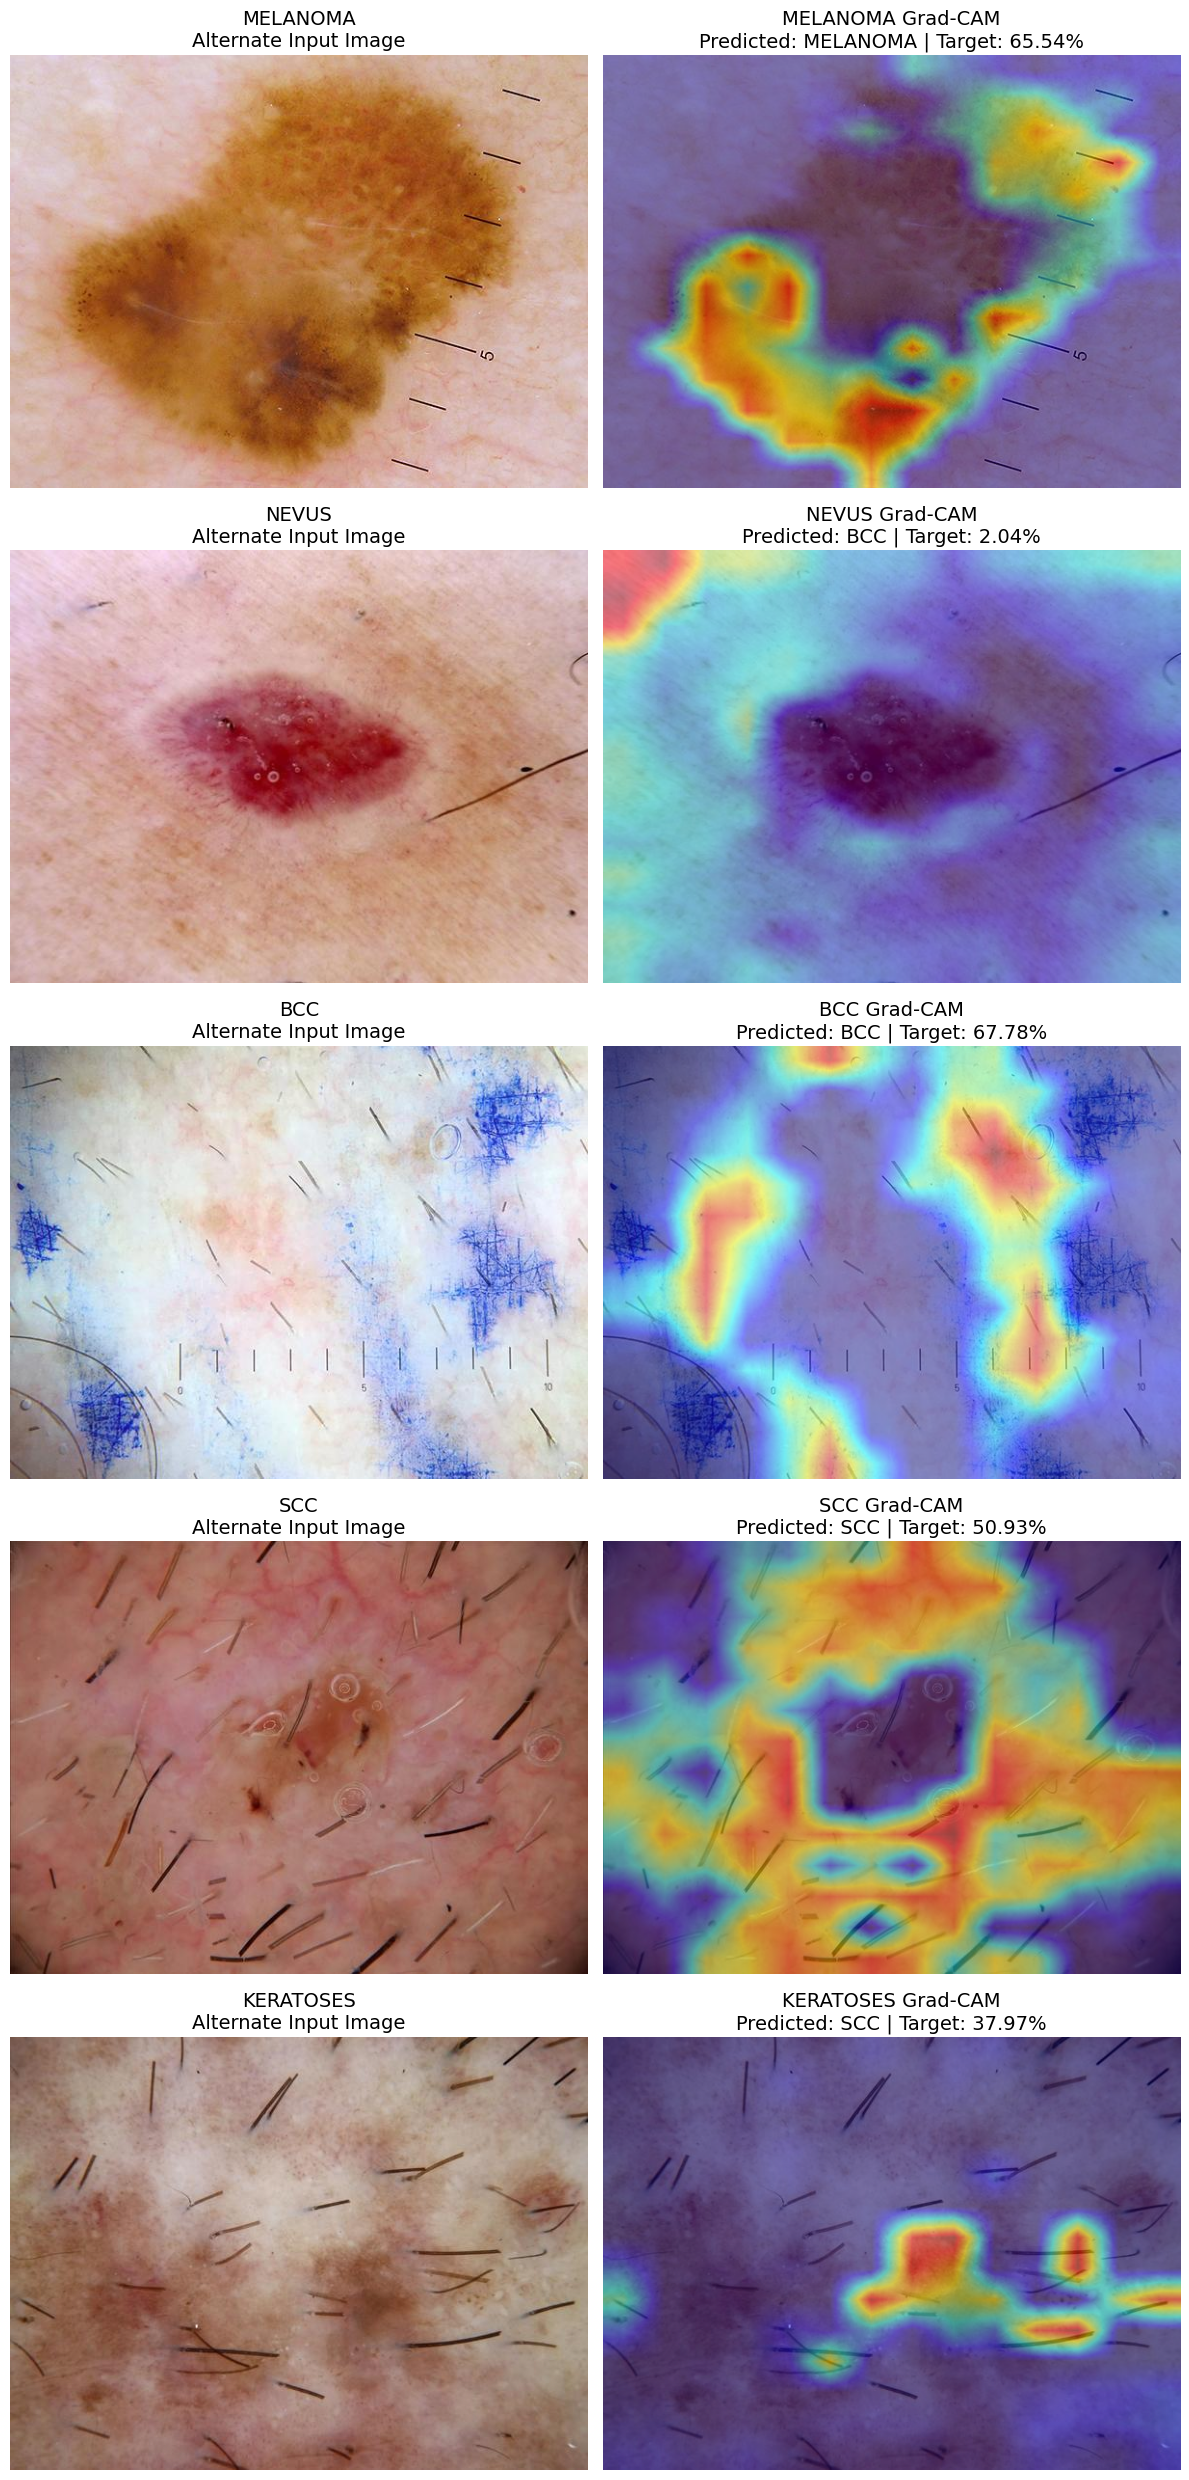



FINAL ALTERNATE IMAGE RESULTS

MELANOMA
Image: /content/data/MILK10k_Split/test/images/ISIC_8521879.jpg
Predicted: melanoma
Target probability: 65.54%

NEVUS
Image: /content/data/MILK10k_Split/test/images/ISIC_7941055.jpg
Predicted: bcc
Target probability: 2.04%

BCC
Image: /content/data/MILK10k_Split/test/images/ISIC_1048297.jpg
Predicted: bcc
Target probability: 67.78%

SCC
Image: /content/data/MILK10k_Split/test/images/ISIC_5186409.jpg
Predicted: scc
Target probability: 50.93%

KERATOSES
Image: /content/data/MILK10k_Split/test/images/ISIC_0856370.jpg
Predicted: scc
Target probability: 37.97%


In [ ]:
#gradcam
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

TEST_DIR = "/content/data/MILK10k_Split/test"

GROUNDTRUTH_PATH = os.path.join(
    TEST_DIR,
    "GroundTruth.csv"
)

METADATA_PATH = os.path.join(
    TEST_DIR,
    "Metadata.csv"
)

IMAGE_DIR = os.path.join(
    TEST_DIR,
    "images"
)

BEST_CHECKPOINT = (
    "/content/drive/MyDrive/"
    "PanDerm_Checkpoints/"
    "best_checkpoint.pth"
)

CLASS_NAMES = [
    "melanoma",
    "nevus",
    "bcc",
    "scc",
    "keratoses"
]

NUM_CLASSES = 5

groundtruth = pd.read_csv(
    GROUNDTRUTH_PATH
)

metadata = pd.read_csv(
    METADATA_PATH
)

print(
    "GroundTruth rows:",
    len(groundtruth)
)

print(
    "Metadata rows   :",
    len(metadata)
)

image_lookup = {}

for root, dirs, files in os.walk(
    IMAGE_DIR
):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            isic_id = os.path.splitext(
                file
            )[0]

            image_lookup[isic_id] = os.path.join(
                root,
                file
            )

print(
    "Images found:",
    len(image_lookup)
)

metadata_lookup = {}

for _, row in metadata.iterrows():

    lesion_id = str(
        row["lesion_id"]
    )

    isic_id = str(
        row["isic_id"]
    )

    if lesion_id not in metadata_lookup:

        metadata_lookup[lesion_id] = []

    metadata_lookup[lesion_id].append(
        isic_id
    )

CLASS_COLUMNS = {
    "melanoma": ["MEL"],
    "nevus": ["NV"],
    "bcc": ["BCC"],
    "scc": ["SCCKA"],
    "keratoses": ["BKL", "AKIEC"]
}

IMAGE_PATHS = {}

for class_name in CLASS_NAMES:

    columns = CLASS_COLUMNS[
        class_name
    ]

    if len(columns) == 1:

        rows = groundtruth[
            groundtruth[columns[0]] == 1
        ]

    else:

        rows = groundtruth[
            (groundtruth[columns[0]] == 1) |
            (groundtruth[columns[1]] == 1)
        ]

    found_images = []

    for _, row in rows.iterrows():

        lesion_id = str(
            row["lesion_id"]
        )

        isic_ids = metadata_lookup.get(
            lesion_id,
            []
        )

        for isic_id in isic_ids:

            image_path = image_lookup.get(
                isic_id
            )

            if image_path is not None:

                found_images.append(
                    image_path
                )

    found_images = list(
        dict.fromkeys(
            found_images
        )
    )

    if len(found_images) < 2:

        raise RuntimeError(
            f"Not enough images for {class_name}. "
            f"Only {len(found_images)} found."
        )

    IMAGE_PATHS[class_name] = found_images[1]

print("\n" + "=" * 70)
print("SELECTED ALTERNATE TEST IMAGES")
print("=" * 70)

for class_name in CLASS_NAMES:

    print(
        f"{class_name:12s} : "
        f"{IMAGE_PATHS[class_name]}"
    )

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

if "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(
        checkpoint
    )

model = model.to(DEVICE)

model.eval()

print(
    "\nPanDerm model loaded successfully."
)

transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

target_layer = model.blocks[-1]

print(
    "\nGrad-CAM target layer:"
)

print(
    target_layer
)

def generate_panderm_gradcam(
    image_path,
    target_class
):

    activations = None
    gradients = None

    original_image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = transform(
        original_image
    ).unsqueeze(0).to(DEVICE)

    def forward_hook(
        module,
        input,
        output
    ):

        nonlocal activations

        activations = output

    def backward_hook(
        module,
        grad_input,
        grad_output
    ):

        nonlocal gradients

        gradients = grad_output[0]

    forward_handle = (
        target_layer.register_forward_hook(
            forward_hook
        )
    )

    backward_handle = (
        target_layer.register_full_backward_hook(
            backward_hook
        )
    )

    model.zero_grad(
        set_to_none=True
    )

    output = model(
        image_tensor
    )

    if hasattr(
        output,
        "logits"
    ):

        logits = output.logits

    elif isinstance(
        output,
        tuple
    ):

        logits = output[0]

    else:

        logits = output

    probabilities = torch.softmax(
        logits,
        dim=1
    )[0]

    predicted_class = torch.argmax(
        probabilities
    ).item()

    score = logits[
        0,
        target_class
    ]

    score.backward()

    if activations is None:

        forward_handle.remove()
        backward_handle.remove()

        raise RuntimeError(
            "Activations were not captured."
        )

    if gradients is None:

        forward_handle.remove()
        backward_handle.remove()

        raise RuntimeError(
            "Gradients were not captured."
        )

    acts = activations.detach()

    grads = gradients.detach()

    acts = acts[:, 1:, :]

    grads = grads[:, 1:, :]

    num_tokens = acts.shape[1]

    embedding_dim = acts.shape[2]

    grid_size = int(
        np.sqrt(num_tokens)
    )

    if (
        grid_size * grid_size
        != num_tokens
    ):

        forward_handle.remove()
        backward_handle.remove()

        raise RuntimeError(
            f"Cannot create spatial map.\n"
            f"Number of tokens = {num_tokens}"
        )

    acts = acts.reshape(
        1,
        grid_size,
        grid_size,
        embedding_dim
    )

    grads = grads.reshape(
        1,
        grid_size,
        grid_size,
        embedding_dim
    )

    acts = acts.permute(
        0,
        3,
        1,
        2
    )

    grads = grads.permute(
        0,
        3,
        1,
        2
    )

    weights = grads.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (
        weights * acts
    ).sum(
        dim=1
    )

    cam = torch.relu(
        cam
    )

    cam = cam[
        0
    ].cpu().numpy()

    cam = (
        cam - cam.min()
    )

    if cam.max() > 0:

        cam = (
            cam / cam.max()
        )

    cam = cv2.resize(
        cam,
        (
            original_image.width,
            original_image.height
        )
    )

    forward_handle.remove()

    backward_handle.remove()

    return (
        original_image,
        cam,
        predicted_class,
        probabilities.detach().cpu().numpy()
    )

results = []

print("\n" + "=" * 70)
print("GENERATING ALTERNATE IMAGE GRAD-CAMS")
print("=" * 70)

for class_index, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"\nProcessing: {class_name}"
    )

    image_path = IMAGE_PATHS[
        class_name
    ]

    (
        original_image,
        cam,
        predicted_class,
        probabilities
    ) = generate_panderm_gradcam(
        image_path,
        class_index
    )

    results.append(
        (
            class_name,
            original_image,
            cam,
            predicted_class,
            probabilities
        )
    )

    print(
        "Predicted:",
        CLASS_NAMES[
            predicted_class
        ]
    )

    print(
        "Target class probability:",
        f"{probabilities[class_index] * 100:.2f}%"
    )

fig, axes = plt.subplots(
    5,
    2,
    figsize=(12, 25)
)

for row, result in enumerate(
    results
):

    (
        target_class,
        original_image,
        cam,
        predicted_class,
        probabilities
    ) = result

    axes[row, 0].imshow(
        original_image
    )

    axes[row, 0].set_title(
        f"{target_class.upper()}\n"
        f"Alternate Input Image",
        fontsize=14
    )

    axes[row, 0].axis(
        "off"
    )

    heatmap = np.uint8(
        255 * cam
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    original_np = np.array(
        original_image
    )

    overlay = cv2.addWeighted(
        original_np,
        0.55,
        heatmap,
        0.45,
        0
    )

    axes[row, 1].imshow(
        overlay
    )

    axes[row, 1].set_title(
        f"{target_class.upper()} Grad-CAM\n"
        f"Predicted: "
        f"{CLASS_NAMES[predicted_class].upper()} | "
        f"Target: "
        f"{probabilities[row] * 100:.2f}%",
        fontsize=14
    )

    axes[row, 1].axis(
        "off"
    )

plt.tight_layout()

plt.show()

print("\n")
print("=" * 70)
print("FINAL ALTERNATE IMAGE RESULTS")
print("=" * 70)

for i, result in enumerate(
    results
):

    (
        target_class,
        original_image,
        cam,
        predicted_class,
        probabilities
    ) = result

    print(
        f"\n{target_class.upper()}"
    )

    print(
        "Image:",
        IMAGE_PATHS[target_class]
    )

    print(
        "Predicted:",
        CLASS_NAMES[predicted_class]
    )

    print(
        "Target probability:",
        f"{probabilities[i] * 100:.2f}%"
    )
```